In [ ]:
!pip install -q diffusers transformers accelerate bitsandbytes

In [ ]:
import torch
from PIL import Image
from IPython.display import display, Image as DisplayGif

def clear_vram():
    torch.cuda.empty_cache()

device = "cuda"

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


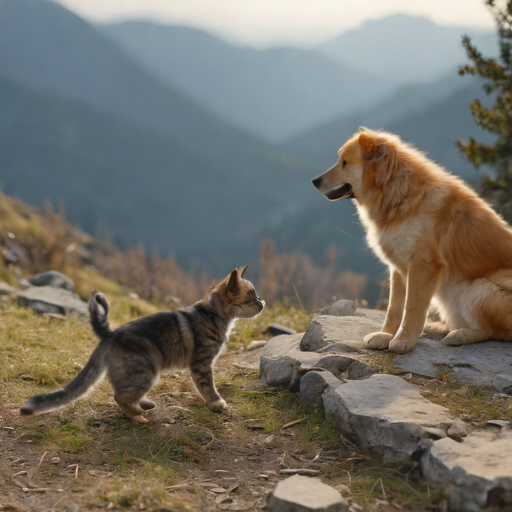

In [ ]:
#Text-to-Image
import torch
from diffusers import AutoPipelineForText2Image

torch.cuda.empty_cache()
device = "cuda"

model_id = "stabilityai/sdxl-turbo"
pipe = AutoPipelineForText2Image.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    variant="fp16"
).to(device)

prompt = "A dog plays with a cat in the mountains, high quality, cinematic"
image_result = pipe(prompt=prompt, num_inference_steps=2, guidance_scale=0.0).images[0]
image_result.save("result_1.png")
image_result

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/25 [00:00<?, ?it/s]

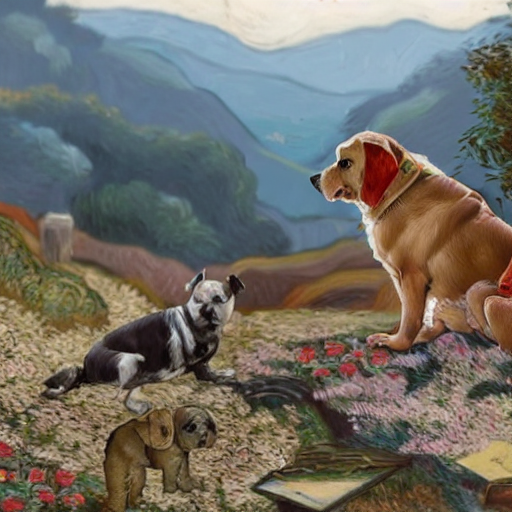

In [ ]:
#Image to image
import torch
from diffusers import StableDiffusionImg2ImgPipeline

torch.cuda.empty_cache()
model_id = "runwayml/stable-diffusion-v1-5"
pipe_i2i = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to("cuda")

pipe_i2i.safety_checker = None
init_image = image_result
prompt = "Add another dog, the whole picture is in the style of Van Gogh.."
final_image = pipe_i2i(prompt=prompt, image=init_image, strength=0.5).images[0]

final_image.save("cyber_dog_cat.png")
final_image

In [ ]:
#Imag to text
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import warnings

warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)
img_path = "123.jpg"
raw_image = Image.open(img_path).convert('RGB')
inputs = processor(raw_image, return_tensors="pt").to(device)
out = model.generate(**inputs)
caption = processor.decode(out[0], skip_special_tokens=True)
print(f"Результат: {caption}")

del model, processor
torch.cuda.empty_cache()

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic


Результат описания: a small dog running through the grass


In [ ]:
#Imag to text
import torch
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "microsoft/git-base-coco"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id).to(device)
image_path = "1234.jpg"
image = Image.open(image_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt").to(device)
generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=50)
caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(f"Резултат:{model_id}:")
print(caption)

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/305 [00:00<?, ?it/s]

GitForCausalLM LOAD REPORT from: microsoft/git-base-coco
Key                                                    | Status     |  | 
-------------------------------------------------------+------------+--+-
git.image_encoder.vision_model.embeddings.position_ids | UNEXPECTED |  | 
git.embeddings.position_ids                            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Результат модели microsoft/git-base-coco:
the cute little strip of sand in the ocean


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

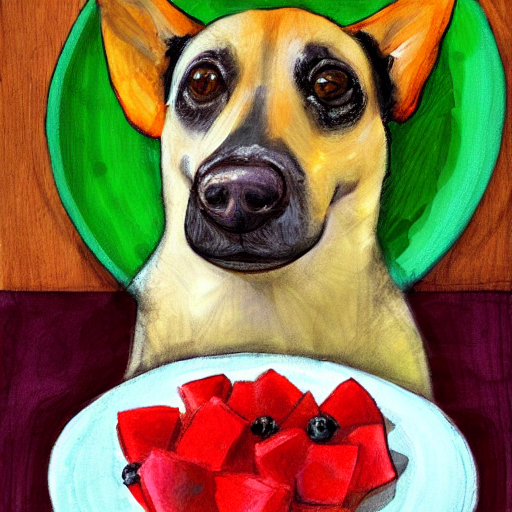

In [ ]:
#Text-to-Image

!pip install diffusers transformers accelerate -q

import torch
from diffusers import StableDiffusionPipeline

torch.cuda.empty_cache()
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to("cuda")

pipe.enable_attention_slicing()
prompt = "a plate of fruit on the table and a dog next to it, digital art"
image = pipe(prompt).images[0]
image.save("final_result.png")
image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.3/270.3 MB 5.4 MB/s eta 0:00:00


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

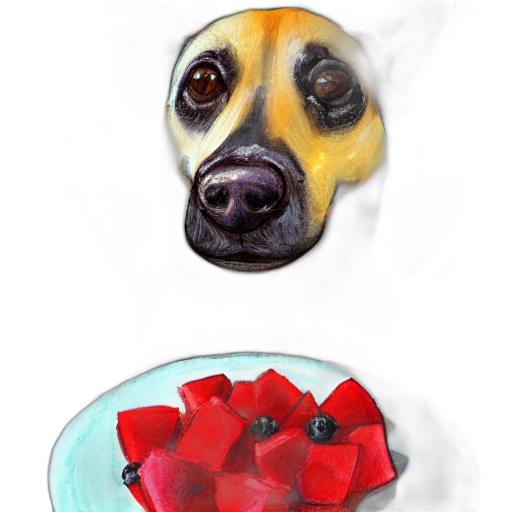

In [ ]:
#Text-to-Image
!pip install rembg[gpu] onnxruntime-gpu -q

from rembg import remove
from PIL import Image

input_path = 'final_result.png'
input_image = Image.open(input_path)
output_image = remove(input_image)
output_image.save('dog_no_bg.png')
output_image

In [ ]:
# Imag to text
!pip install "pydantic<2" transformers torch pillow -q

import torch
from transformers import BlipProcessor, BlipForQuestionAnswering
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "Salesforce/blip-vqa-base"

processor = BlipProcessor.from_pretrained(model_id)
model = BlipForQuestionAnswering.from_pretrained(model_id).to(device)

image = Image.open("final_result.png").convert("RGB")
question = "What is on the table in front of the dog?"
inputs = processor(image, question, return_tensors="pt").to(device)
out = model.generate(**inputs)
answer = processor.decode(out[0], skip_special_tokens=True)

print(f"Вопрс: {question}")
print(f"Ответ: {answer}")

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Вопрос: What is on the table in front of the dog?
Ответ: plate
